# Aufgabe 12.4 – Klassifikationsmodell für defekte Flaschen

Ziel: Vorhersage ob eine Flasche defekt ist (`is_cracked`) anhand der `drop_oscillation` Zeitreihe (500 Messwerte je Flasche).

In [1]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, f1_score

## 1. Daten laden & drop_oscillation parsen

Die `drop_oscillation` Spalte ist als JSON-String gespeichert (Liste mit 500 Werten). Wir parsen sie in ein NumPy-Array.

In [2]:
df = pd.read_csv('data.csv')
df = df.dropna(subset=['drop_oscillation', 'is_cracked'])

# drop_oscillation von String zu Liste parsen
df['drop_oscillation'] = df['drop_oscillation'].apply(ast.literal_eval)
df['drop_oscillation'] = df['drop_oscillation'].apply(lambda x: [float(v) for v in x])

print(f'Flaschen gesamt:  {len(df)}')
print(f'Davon defekt:     {df["is_cracked"].sum()}')
print(f'Davon intakt:     {(df["is_cracked"] == 0).sum()}')
df.head(3)

Flaschen gesamt:  636
Davon defekt:     45
Davon intakt:     591


,bottle,recipe,fill_level_grams_red,vibration_index_red,time_red,temperature_C_red,fill_level_grams_blue,vibration_index_blue,time_blue,temperature_C_blue,fill_level_grams_green,vibration_index_green,time_green,temperature_C_green,final_weight,time_scale,is_cracked,drop_oscillation
0,80585489,3,623.240892,86.722805,1780650235,32.355647,846.736547,-21.523238,1780650239,33.482129,0.000000,-15.432611,1780650243,32.716305,10.422501,1780650245,0,"[0.0, 0.8265280184, 1.2577888062, 2.2381129382..."
1,80585491,3,616.626970,83.834205,1780650239,32.644641,846.495462,-15.780005,1780650243,32.573862,788.343641,158.883278,1780650247,32.658978,28.394977,1780650249,0,"[0.0, -0.0042422357, 0.211720551, 0.0759635348..."
2,80585493,3,610.103457,82.510405,1780650243,32.178065,846.135847,-12.192027,1780650247,31.740672,776.171876,164.606564,1780650251,33.929484,29.178344,1780650253,0,"[0.0, 0.3612517982, 0.6557609528, 0.8989050835..."


## 2. Feature Engineering

Wir extrahieren aus der 500-Werte-Zeitreihe folgende Features:
- **mean** – Mittelwert
- **std** – Standardabweichung
- **max** – Maximum
- **min** – Minimum
- **lag1** – letzter Wert (yt-1)
- **Fourier-Koeffizienten** – Frequenzanteile (erste 10)

In [3]:
# Statistische Features
df['mean']  = df['drop_oscillation'].apply(np.mean)
df['std']   = df['drop_oscillation'].apply(np.std)
df['min']   = df['drop_oscillation'].apply(np.min)
df['max']   = df['drop_oscillation'].apply(np.max)
# df['lag1']  = df['drop_oscillation'].apply(lambda x: x[-1])  # letzter Wert
df["range"] = df["max"] - df["min"]
df["median"] = df["drop_oscillation"].apply(np.median)
df["rms"] = df["drop_oscillation"].apply(lambda x: np.sqrt(np.mean(np.square(x))))

# Fourier-Features (Betrag der ersten 10 Frequenzkomponenten)
for i in range(1, 11):
    df[f'freq_{i}'] = df['drop_oscillation'].apply(lambda x: np.abs(np.fft.fft(x))[i])

print('Features erstellt:')
df[["rms", "mean", "std", "min", "max", "range", "median"]].head()

Features erstellt:


,rms,mean,std,min,max,range,median
0,1.419561,-0.079256,1.417347,-3.139332,3.327738,6.467071,-0.160215
1,0.226385,-0.005865,0.226309,-0.841293,1.007755,1.849048,-0.003555
2,0.719336,0.041411,0.718143,-1.706650,1.817184,3.523834,0.037325
3,0.119186,0.008280,0.118898,-0.505022,0.688265,1.193287,0.000710
4,0.272380,0.008519,0.272247,-1.562640,1.086520,2.649160,0.000923


## 3. Daten visualisieren

Vergleich von intakten und defekten Flaschen anhand von Mittelwert und Standardabweichung.

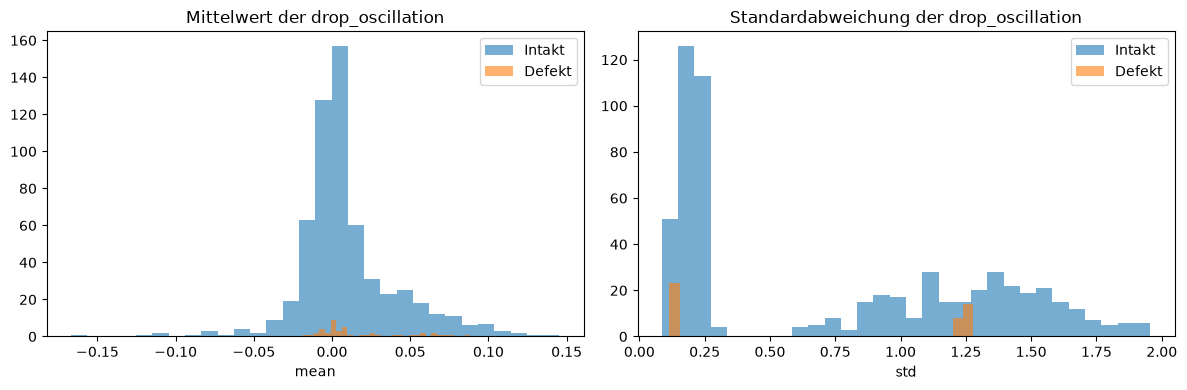

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, group in df.groupby('is_cracked'):
    name = 'Defekt' if label == 1 else 'Intakt'
    axes[0].hist(group['mean'], bins=30, alpha=0.6, label=name)
    axes[1].hist(group['std'],  bins=30, alpha=0.6, label=name)

axes[0].set_title('Mittelwert der drop_oscillation')
axes[0].set_xlabel('mean')
axes[0].legend()

axes[1].set_title('Standardabweichung der drop_oscillation')
axes[1].set_xlabel('std')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Feature-Kombinationen testen

Wir testen verschiedene Feature-Kombinationen mit drei Modellen (kNN, Logistische Regression, Decision Tree) und berechnen jeweils den F1-Score auf Trainings- und Testdaten.

In [5]:
y = df['is_cracked'].astype(int)

feature_sets = {
    "rms": ["rms"],
    "mean, std": ["mean", "std"],
    "min, max, range": ["min", "max", "range"],
    "rms, mean, std": ["rms", "mean", "std"],
    "rms, mean, std, min, max": ["rms", "mean", "std", "min", "max"],
    "alle statistischen Features": ["rms", "mean", "std", "min", "max", "range", "median"],
}

models = {
    'kNN':              KNeighborsClassifier(n_neighbors=5),
    'Log. Regression':  LogisticRegression(max_iter=1000),
    'Decision Tree':    DecisionTreeClassifier(max_depth=4, random_state=42),
}

results = []

for feat_name, features in feature_sets.items():
    X = df[features]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Standardisierung
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    for model_name, model in models.items():
        model.fit(X_train_s, y_train)
        f1_train = f1_score(y_train, model.predict(X_train_s), zero_division=0)
        f1_test  = f1_score(y_test,  model.predict(X_test_s),  zero_division=0)
        results.append({
            'Features':        feat_name,
            'Modell':          model_name,
            'F1 (Training)':   round(f1_train, 4),
            'F1 (Test)':       round(f1_test, 4),
        })

results_df = pd.DataFrame(results)
results_df
results_df.to_csv("classification_feature_results.csv", index=False)
results_df

,Features,Modell,F1 (Training),F1 (Test)
0,rms,kNN,0.7342,0.5000
1,rms,Log. Regression,0.0000,0.0000
2,rms,Decision Tree,0.8205,0.5217
3,"mean, std",kNN,0.6377,0.5714
4,"mean, std",Log. Regression,0.0000,0.0000
5,"mean, std",Decision Tree,0.8354,0.6400
6,"min, max, range",kNN,0.2857,0.0000
7,"min, max, range",Log. Regression,0.0000,0.0000
8,"min, max, range",Decision Tree,0.5490,0.2353
9,"rms, mean, std",kNN,0.6765,0.5455


## 5. Bestes Modell – Confusion Matrix & Classification Report

Bestes Modell: Decision Tree mit Features: mean, std
F1 Test: 0.64


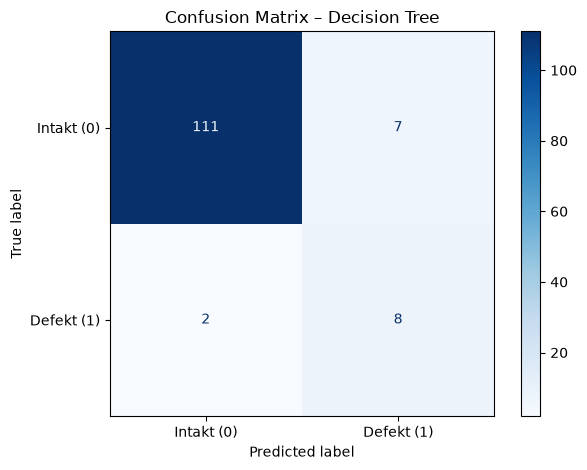


Classification Report (Testdaten):
              precision    recall  f1-score   support

  Intakt (0)       0.98      0.94      0.96       118
  Defekt (1)       0.53      0.80      0.64        10

    accuracy                           0.93       128
   macro avg       0.76      0.87      0.80       128
weighted avg       0.95      0.93      0.94       128



In [6]:
# Bestes Modell anhand F1 Test auswählen
best_row = results_df.loc[results_df['F1 (Test)'].idxmax()]
print(f"Bestes Modell: {best_row['Modell']} mit Features: {best_row['Features']}")
print(f"F1 Test: {best_row['F1 (Test)']}")

best_features = feature_sets[best_row['Features']]
best_model_name = best_row['Modell']

model_map = {
    'kNN':             KNeighborsClassifier(n_neighbors=5),
    'Log. Regression': LogisticRegression(max_iter=1000),
    'Decision Tree':   DecisionTreeClassifier(max_depth=4, random_state=42),
}

X = df[best_features]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

best_model = model_map[best_model_name]
best_model.fit(X_train_s, y_train)
y_pred = best_model.predict(X_test_s)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Intakt (0)', 'Defekt (1)'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix – {best_model_name}')
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

# Classification Report
print('\nClassification Report (Testdaten):')
print(classification_report(y_test, y_pred, target_names=['Intakt (0)', 'Defekt (1)']))